# Experiment 2 — learning curves (LGD)

How R² scales with the amount of available data (no HPO; LinearRegression, TabICLv2, TabPFN-v3, and CatBoost). The swept `row_limit` caps the **dataset before the CV split** — train and test shrink together — so the x-axis is the **dataset size**, not the training-set size. Same structure as the PD notebook. Figures → `figures/experiment2/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, learning_curve_moving_average_with_dots,
    imbalance_curve, imbalance_curve_moving_average_with_dots, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2/lgd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2\lgd


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment2', task='lgd', aggregated=False)
DISPLAY_METHODS = ['LinearRegression', 'tabicl_v2', 'tabpfn_v3', 'catboost']
missing = sorted(set(DISPLAY_METHODS) - set(df['method']))
if missing:
    print('Missing display methods:', ', '.join(missing))
df = df[df['method'].isin(DISPLAY_METHODS)].copy()
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

4 methods, 4 datasets, 451 sweep points


## 1. R? vs dataset size ? pooled over datasets

Views of the same curve (one line per method, mean over datasets):
1. **learning curve** with raw sweep points,
2. the same learning curve with a **lower-right inset** zooming the shaded `rows <= 1000` region,
3. **moving average** (trend),
4. **moving average with transparent raw points**.


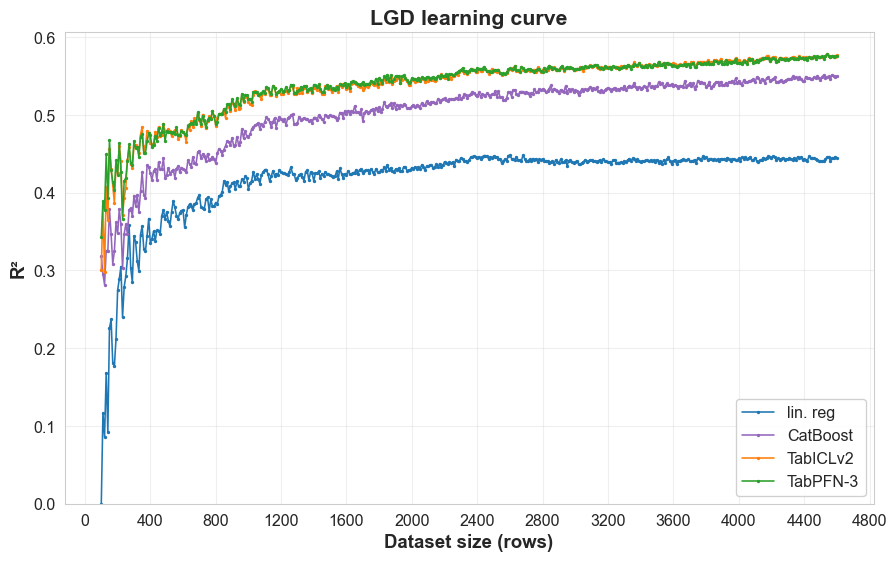

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2.pdf')

In [3]:
learning_curve(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)


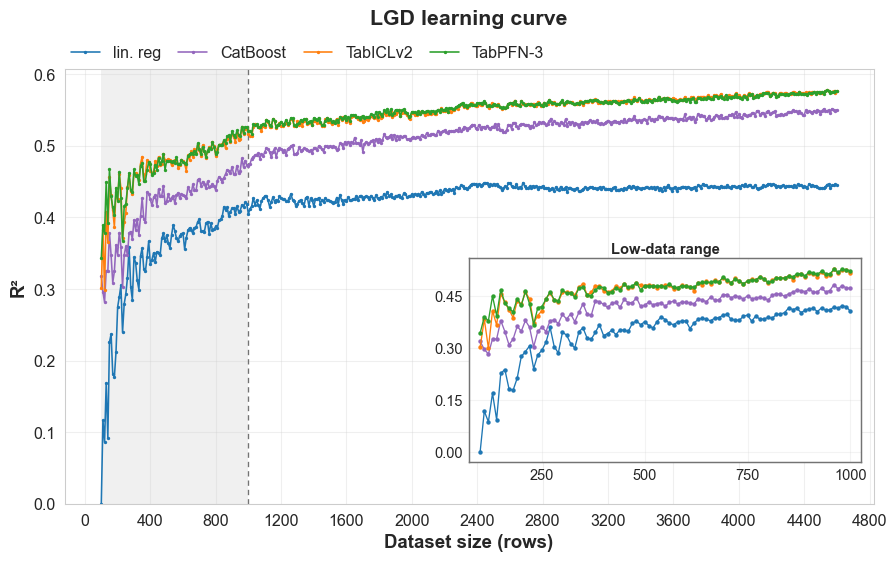

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_zoom.pdf')

In [4]:
learning_curve(df, 'R2', task_name='LGD', zoom=True, out_dir=FIGURES_DIR)


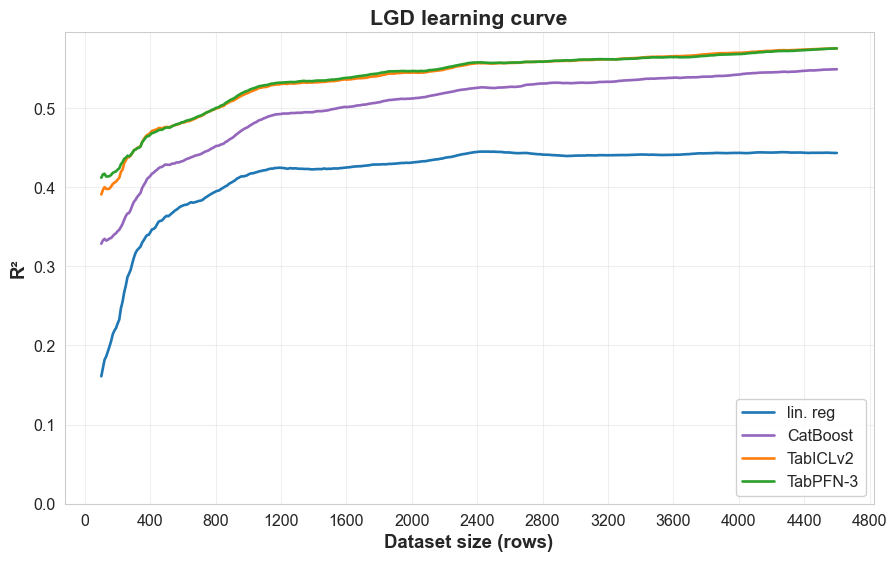

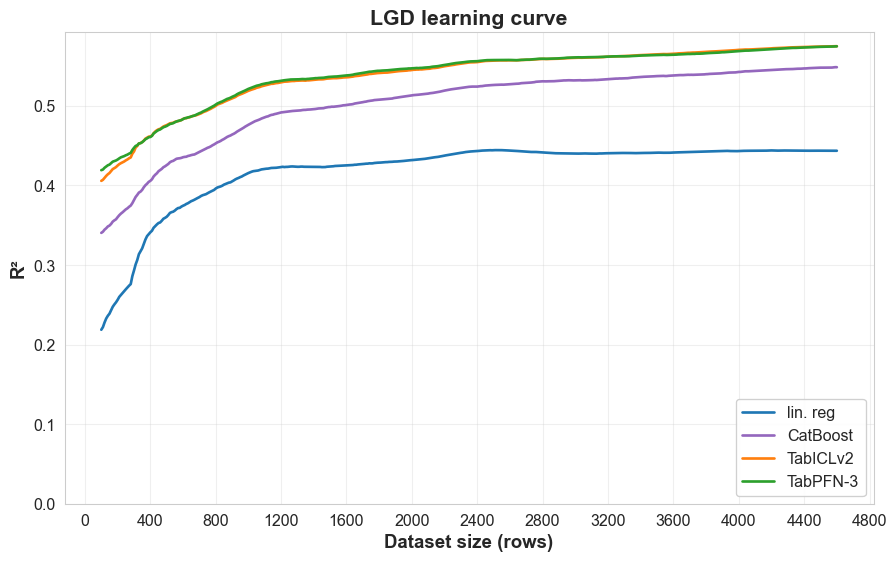

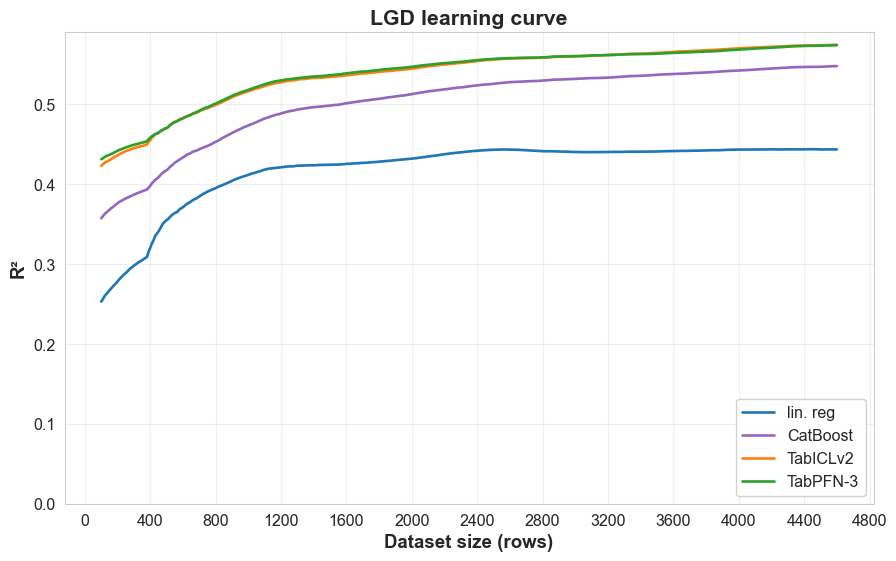

In [5]:
for smooth_window in ('less', 'standard', 'more'):
    learning_curve(df, 'R2', task_name='LGD', smooth=True, smooth_window=smooth_window, out_dir=FIGURES_DIR)


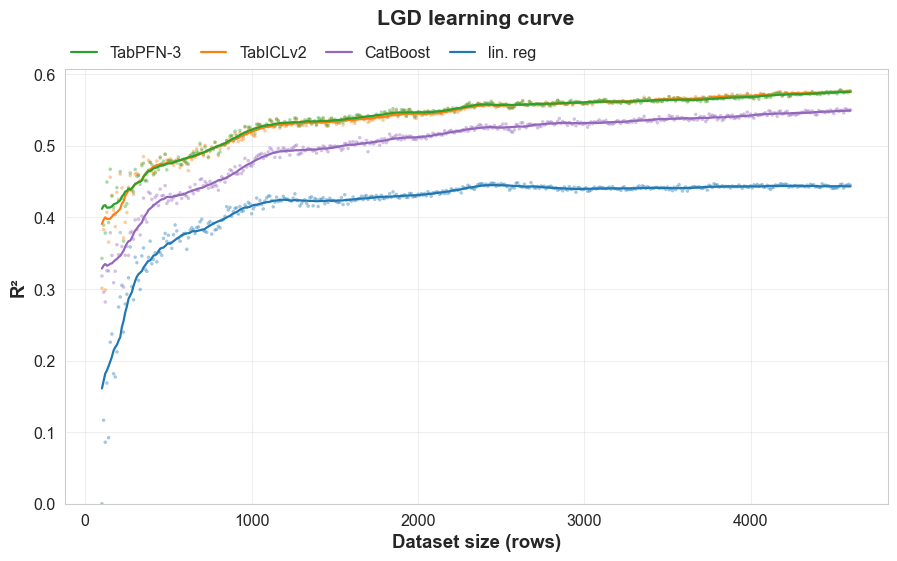

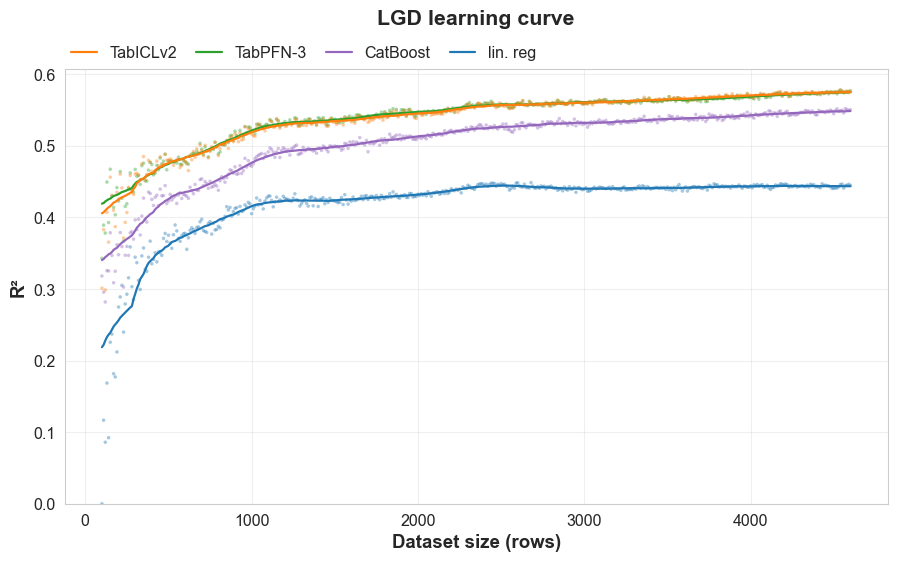

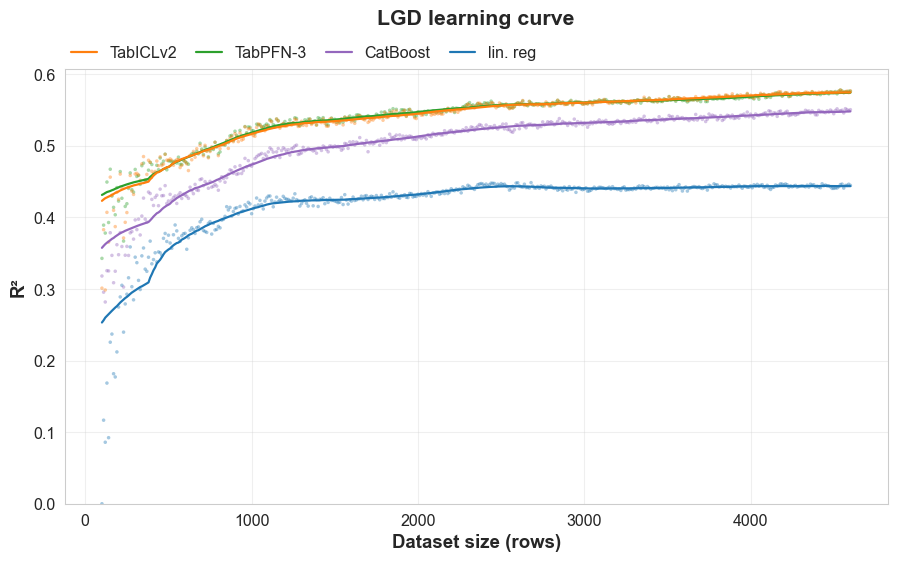

In [6]:
for smooth_window in ('less', 'standard', 'more'):
    learning_curve_moving_average_with_dots(df, 'R2', task_name='LGD', smooth_window=smooth_window, out_dir=FIGURES_DIR)


## 2. R² per dataset (raw points, all methods)

One plot per dataset so per-dataset behaviour is visible, not only the pooled mean.

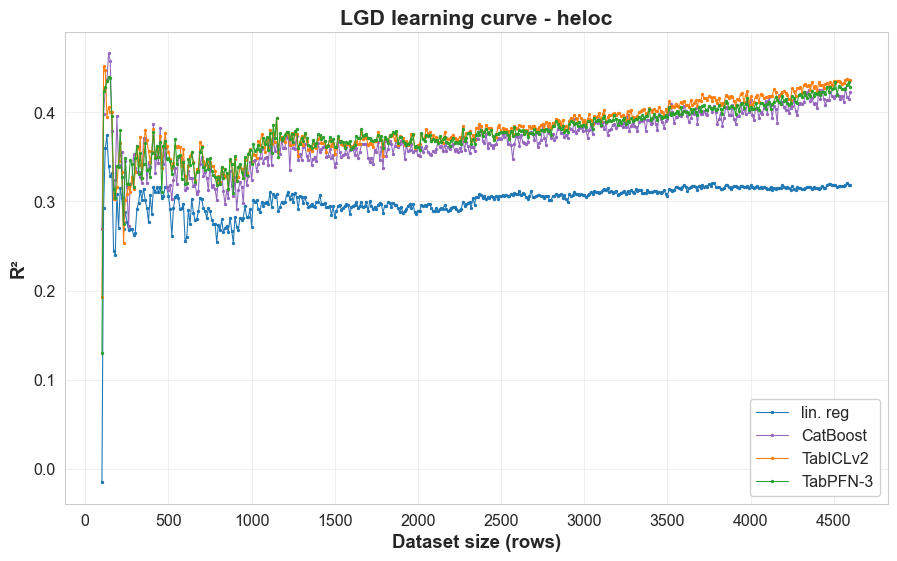

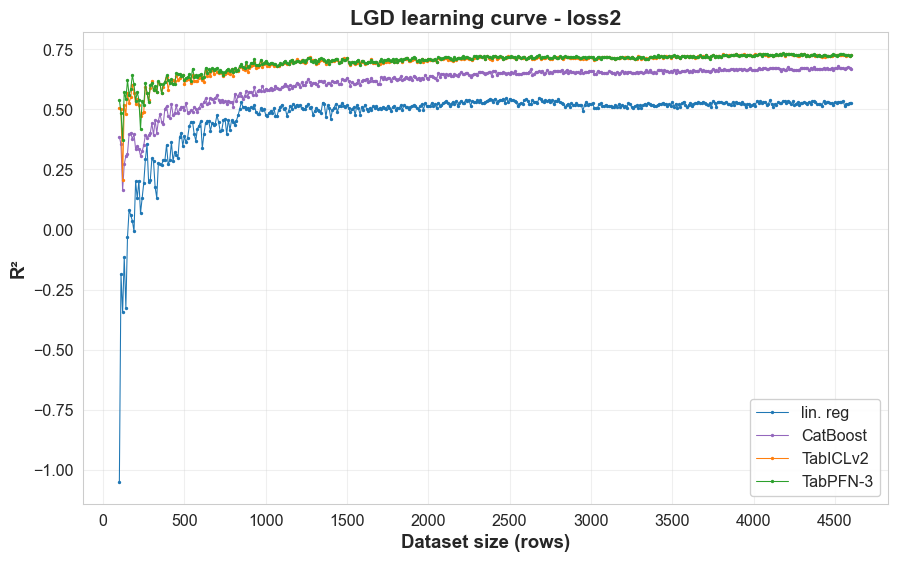

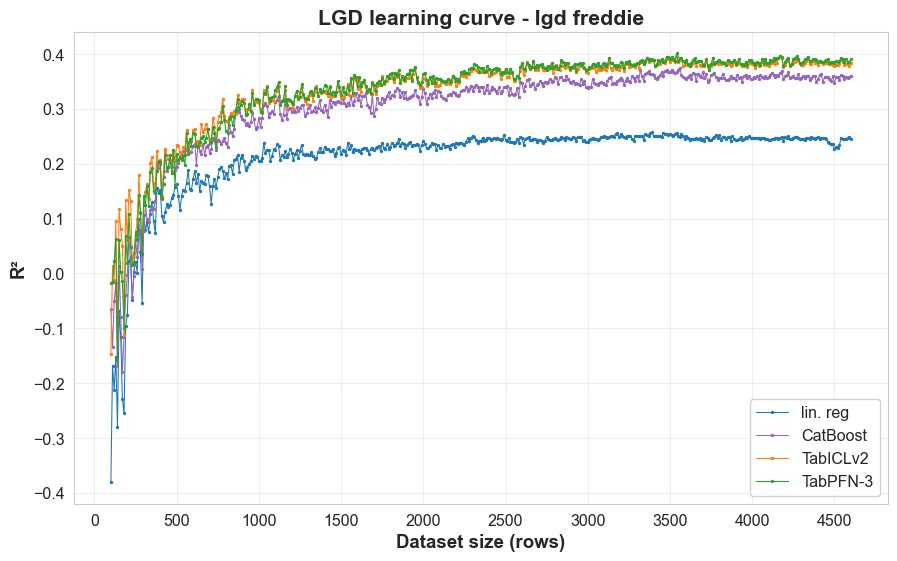

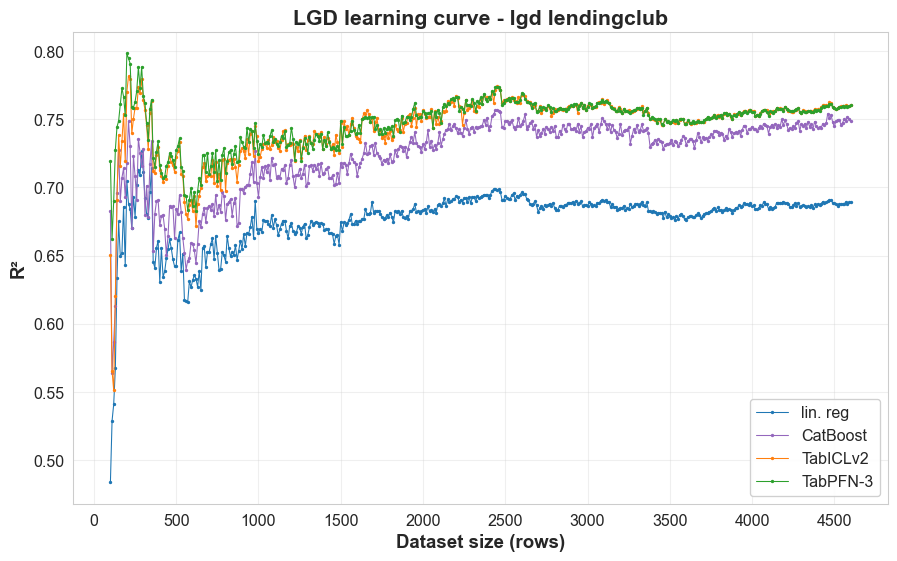

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0001_heloc_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0002_loss2_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0006_lgd_freddie_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0007_lgd_lendingclub_r2.pdf')]

In [7]:
per_dataset_sweep_curves(df, 'R2', sweep_axis='row_limit', xlabel='Dataset size (rows)', task_name='LGD', out_dir=FIGURES_DIR)

## 3. Data efficiency — dataset rows to reach 95% of each method's own plateau

In [8]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.R2'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.R2'].max() * 0.95
    hit = gg[gg['metric.R2'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
display(_pd.Series(rows, name='dataset rows to reach 95% of own max R2').sort_values())

LinearRegression    1030
tabpfn_v3           1830
tabicl_v2           1920
catboost            2290
Name: dataset rows to reach 95% of own max R2, dtype: int64

## 4. Summary — R² evolution over dataset size

Mean R² per method across all datasets at a spread of dataset sizes.

In [9]:
sweep_evolution_summary(df, 'R2', sweep_axis='row_limit',
                        task_name='Experiment 2 — LGD', log_spacing=True, n_points=18)

Experiment 2 — LGD — R² evolution over row_limit  (mean across 4 datasets; 18 of 451 sweep points; best average first)
sweep_value         100     130     160     200     250     310     390     480     610     760     950     1190    1490    1870    2340    2930    3670    4600
method                                                                                                                                                          
tabpfn_v3         0.3426  0.4492  0.4296  0.4227  0.4189  0.4571  0.4768  0.4882  0.4761  0.4964  0.5129  0.5306  0.5352  0.5508  0.5537  0.5579  0.5655  0.5761
tabicl_v2         0.3011  0.4069  0.4307  0.4252  0.4066  0.4614  0.4768  0.4879  0.4746  0.4983  0.5092  0.5311  0.5331  0.5484  0.5527  0.5568  0.5685  0.5765
catboost          0.3180  0.3254  0.3468  0.3477  0.3594  0.3828  0.4332  0.4442  0.4294  0.4421  0.4652  0.4971  0.4978  0.5148  0.5216  0.5295  0.5436  0.5503
LinearRegression -0.2412  0.1685  0.2369  0.2747  0.2926  0.3366  0.3667  0.

"Experiment 2 — LGD — R² evolution over row_limit  (mean across 4 datasets; 18 of 451 sweep points; best average first)\n======================================================================================================================\nsweep_value         100     130     160     200     250     310     390     480     610     760     950     1190    1490    1870    2340    2930    3670    4600\nmethod                                                                                                                                                          \ntabpfn_v3         0.3426  0.4492  0.4296  0.4227  0.4189  0.4571  0.4768  0.4882  0.4761  0.4964  0.5129  0.5306  0.5352  0.5508  0.5537  0.5579  0.5655  0.5761\ntabicl_v2         0.3011  0.4069  0.4307  0.4252  0.4066  0.4614  0.4768  0.4879  0.4746  0.4983  0.5092  0.5311  0.5331  0.5484  0.5527  0.5568  0.5685  0.5765\ncatboost          0.3180  0.3254  0.3468  0.3477  0.3594  0.3828  0.4332  0.4442  0.4294  0.4421  0.4652  0.497